# Job Shop Scheduling Problem: ROA Group 20 (JSSP) 

# Trajectory based - Hill Climbing



# 1. Imports

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import time
import random



# 2. Read instance from jobshop.txt


In [2]:
def read_instance(filepath, target_instance = 0):
    instances = {}
    with open(filepath) as file:
        lines = [l.rstrip() for l in file] #reads line and remove spaces from rightside
        #print(lines[:3])
    i = 0
    while i < len(lines):
        m = re.match(r'\s*instance\s+(\S+)', lines[i]) #read all instances
        if m:
            instance_name = m.group(1)
            #print(instance_name) #
            i += 1
            while i < len(lines) and re.match(r'\s*[+\-=*]{3,}', lines[i]): #skit i e.g. + tecken
                i += 1
            while i < len(lines) and not re.match(r'\s*\d+\s+\d+\s*$', lines[i]): #fokus på å hitta "shape"
                i += 1
            if i >= len(lines):
                break
            parts = lines[i].split()
            #print(parts) #
            n_jobs, n_machines = int(parts[0]), int(parts[1])
            #print(n_jobs, "x" , n_machines, "\n") #
            i += 1
            jobs = []
            for _ in range(n_jobs):
                nums = list(map(int, lines[i].split()))
                jobs.append([(nums[k], nums[k+1]) for k in range(0, len(nums), 2)])
                i += 1
            instances[instance_name] = {'jobs': jobs, 'n_jobs': n_jobs, 'n_machines': n_machines} #spara dina inst. i dictionary
            if target_instance and instance_name == target_instance:
                break
        else:
            i += 1
    return instances


# TESTAR PÅ "FT06"
FILEPATH       = "C:/Skrivbord/.ML/Randomized_optimization_algorithm/1/jobshop.txt"
INSTANCE_NAME  = "abz5"

instances  = read_instance(FILEPATH, target_instance=INSTANCE_NAME)
inst       = instances[INSTANCE_NAME]
jobs       = inst['jobs']
n_jobs     = inst['n_jobs']
n_machines = inst['n_machines']

print(f"Instance : {INSTANCE_NAME}")
print(f"Jobs     : {n_jobs}")
print(f"Machines : {n_machines}")
print(jobs)
print(len(jobs))

Instance : abz5
Jobs     : 10
Machines : 10
[[(4, 88), (8, 68), (6, 94), (5, 99), (1, 67), (2, 89), (9, 77), (7, 99), (0, 86), (3, 92)], [(5, 72), (3, 50), (6, 69), (4, 75), (2, 94), (8, 66), (0, 92), (1, 82), (7, 94), (9, 63)], [(9, 83), (8, 61), (0, 83), (1, 65), (6, 64), (5, 85), (7, 78), (4, 85), (2, 55), (3, 77)], [(7, 94), (2, 68), (1, 61), (4, 99), (3, 54), (6, 75), (5, 66), (0, 76), (9, 63), (8, 67)], [(3, 69), (4, 88), (9, 82), (8, 95), (0, 99), (2, 67), (6, 95), (5, 68), (7, 67), (1, 86)], [(1, 99), (4, 81), (5, 64), (6, 66), (8, 80), (2, 80), (7, 69), (9, 62), (3, 79), (0, 88)], [(7, 50), (1, 86), (4, 97), (3, 96), (0, 95), (8, 97), (2, 66), (5, 99), (6, 52), (9, 71)], [(4, 98), (6, 73), (3, 82), (2, 51), (1, 71), (5, 94), (7, 85), (0, 62), (8, 95), (9, 79)], [(0, 94), (6, 71), (3, 81), (7, 85), (1, 66), (2, 90), (4, 76), (5, 58), (8, 93), (9, 97)], [(3, 50), (0, 59), (1, 82), (8, 67), (7, 56), (9, 96), (6, 58), (4, 81), (5, 59), (2, 96)]]
10


# 3. Makespan calculator

In [3]:
def makespan(chromosome, jobs):
    n_jobs     = len(jobs)
    job_step   = [0] * n_jobs
    job_end    = [0] * n_jobs
    machine_end = [0] * n_machines
    schedule   = defaultdict(list) #store schedule for each machine in dictionary

    for job in chromosome:
        step = job_step[job]
        if step >= len(jobs[job]):
            continue
        machine, duration = jobs[job][step]
        start  = max(job_end[job], machine_end[machine])
        finish = start + duration
        schedule[machine].append((job, start, finish))
        machine_end[machine] = finish
        job_end[job]         = finish
        job_step[job]       += 1
        #print(machine_end)

    return max(machine_end), dict(schedule)


def random_chromosome(n_jobs, n_machines):
    chrom = [j for j in range(n_jobs) for _ in range(n_machines)]
    np.random.shuffle(chrom)
    return chrom


chrom = random_chromosome(n_jobs, n_machines)
make_span, schedule = makespan(chrom, jobs)
print(f"Random chromosome makespan: {make_span}")
print(schedule)

Random chromosome makespan: 2000
{7: [(3, 0, 94), (6, 94, 144), (8, 660, 745), (9, 745, 801), (5, 1075, 1144), (2, 1144, 1222), (4, 1305, 1372), (7, 1372, 1457), (0, 1594, 1693), (1, 1693, 1787)], 0: [(8, 0, 94), (2, 383, 466), (9, 466, 525), (6, 529, 624), (4, 769, 868), (1, 1061, 1153), (3, 1378, 1454), (5, 1454, 1542), (7, 1542, 1604), (0, 1693, 1779)], 1: [(5, 0, 99), (6, 144, 230), (9, 525, 607), (7, 607, 678), (3, 678, 739), (8, 745, 811), (2, 811, 876), (0, 876, 943), (4, 1372, 1458), (1, 1458, 1540)], 3: [(4, 0, 69), (9, 69, 119), (7, 328, 410), (6, 433, 529), (1, 529, 579), (8, 579, 660), (3, 992, 1046), (5, 1206, 1285), (2, 1687, 1764), (0, 1779, 1871)], 4: [(4, 69, 157), (7, 157, 255), (5, 255, 336), (6, 336, 433), (0, 433, 521), (1, 818, 893), (3, 893, 992), (8, 992, 1068), (2, 1222, 1307), (9, 1307, 1388)], 5: [(5, 336, 400), (1, 400, 472), (7, 678, 772), (0, 772, 871), (2, 940, 1025), (8, 1068, 1126), (4, 1237, 1305), (3, 1312, 1378), (6, 1378, 1477), (9, 1477, 1536)], 6:

# 4. Operators (swap, insert, reverse a segment)

In [4]:
def swap_adjacent(chrom):
    c = chrom[:]
    i = random.randrange(len(c) - 1)
    c[i], c[i+1] = c[i+1], c[i]
    return c


def insert_move(chrom):
    c = chrom[:]
    i = random.randrange(len(c))
    j = random.randrange(len(c))
    elem = c.pop(i)
    c.insert(j, elem)
    return c


def reverse_segment(chrom):
    c = chrom[:]
    i, j = sorted(random.sample(range(len(c)), 2))
    c[i:j+1] = c[i:j+1][::-1]
    return c


OPERATORS = [swap_adjacent, insert_move, reverse_segment]

# 5. HC Agorithm

In [ ]:
def hill_climbing(jobs, n_jobs, n_machines,
                  max_iter=10_000,
                  operator=None):

    current    = random_chromosome(n_jobs, n_machines)
    current_ms = makespan(current, jobs)[0]
    history    = [current_ms]

    for _ in range(max_iter):
        # Pick operator
        op        = operator if operator else random.choice(OPERATORS)
        neighbour = op(current)
        nb_ms     = makespan(neighbour, jobs)[0]

        if nb_ms <= current_ms:
            current    = neighbour
            current_ms = nb_ms

        history.append(current_ms)

    return current, current_ms, history


def random_restart_hill_climbing(jobs, n_jobs, n_machines,
                                  max_iter=10_000,
                                  n_restarts=10):

    iters_per_restart = max(1, max_iter // n_restarts)
    best_chrom   = None
    best_ms      = float('inf')
    full_history = []

    for restart in range(n_restarts):
        chrom, ms, hist = hill_climbing(
            jobs, n_jobs, n_machines,
            max_iter=iters_per_restart
        )
        full_history.extend(hist)

        if ms < best_ms:
            best_ms    = ms
            best_chrom = chrom[:]

    return best_chrom, best_ms, full_history


# 6 Run code

In [14]:
KNOWN_OPTIMAL = {
    'ft06': 55, 'ft10': 930, 'ft20': 1165,
    'la01': 666, 'la02': 655, 'la03': 597,
    'abz5': 1234, 'abz6': 943,
}

MAX_ITER  = 50_000
RESTARTS  = 10

print(f"Running on instance: {INSTANCE_NAME}  "
      f"(optimal = {KNOWN_OPTIMAL.get(INSTANCE_NAME, 'unknown')})")
print("-" * 50)

# 1. Single HC
t0 = time.time()
hc_chrom, hc_ms, hc_hist = hill_climbing(
    jobs, n_jobs, n_machines, max_iter=MAX_ITER
)
hc_time = time.time() - t0
print(f"Single HC            makespan = {hc_ms:6d}   time = {hc_time:.2f}s")

# 2. Random-Restart HC
t0 = time.time()
rr_chrom, rr_ms, rr_hist = random_restart_hill_climbing(
    jobs, n_jobs, n_machines, max_iter=MAX_ITER, n_restarts=RESTARTS
)
rr_time = time.time() - t0
print(f"Random-Restart HC    makespan = {rr_ms:6d}   time = {rr_time:.2f}s")

# 3. Per-operator HC
op_results = {}
for op in OPERATORS:
    _, op_ms, op_hist = hill_climbing(
        jobs, n_jobs, n_machines,
        max_iter=MAX_ITER, operator=op
    )
    op_results[op.__name__] = (op_ms, op_hist)
    print(f"HC ({op.__name__:<20}) makespan = {op_ms:6d}")

Running on instance: abz5  (optimal = 1234)
--------------------------------------------------
Single HC            makespan =   1266   time = 1.79s
Random-Restart HC    makespan =   1258   time = 1.83s
HC (swap_adjacent       ) makespan =   1352
HC (insert_move         ) makespan =   1264
HC (reverse_segment     ) makespan =   1290


# 7

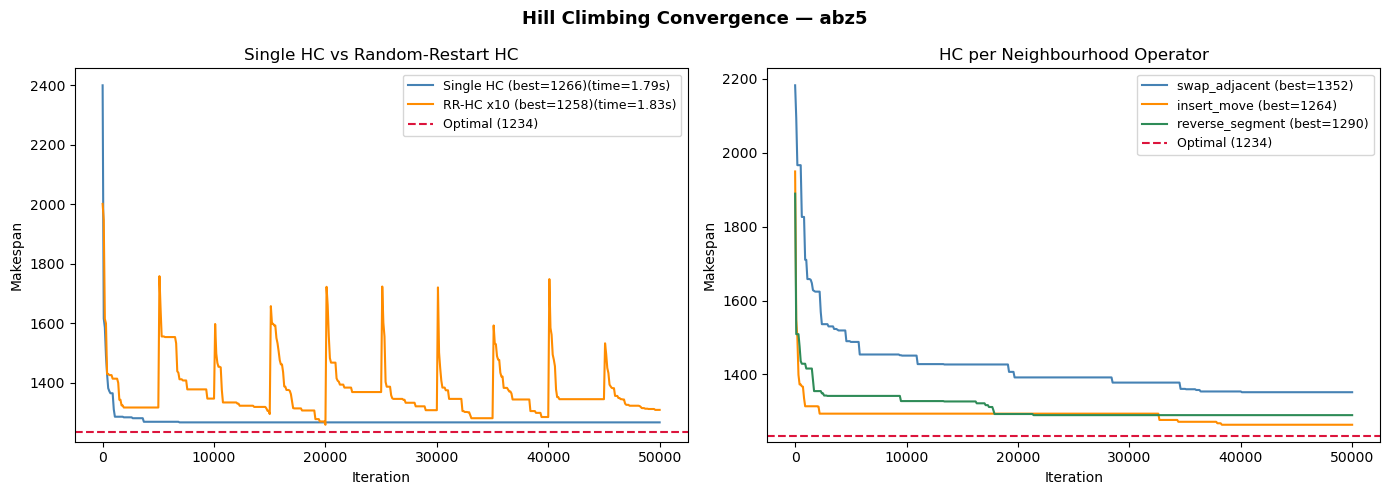

In [15]:
opt = KNOWN_OPTIMAL.get(INSTANCE_NAME)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Hill Climbing Convergence — {INSTANCE_NAME}", fontsize=13, fontweight='bold')

# Left: Single HC vs Random-Restart HC
ax = axes[0]
step = max(1, len(hc_hist) // 500)
ax.plot(range(0, len(hc_hist), step),
        [hc_hist[i] for i in range(0, len(hc_hist), step)],
        color='steelblue', lw=1.5, label=f'Single HC (best={hc_ms})(time={hc_time:.2f}s)')
step2 = max(1, len(rr_hist) // 500)
ax.plot(range(0, len(rr_hist), step2),
        [rr_hist[i] for i in range(0, len(rr_hist), step2)],
        color='darkorange', lw=1.5, label=f'RR-HC x{RESTARTS} (best={rr_ms})(time={rr_time:.2f}s)')
if opt:
    ax.axhline(opt, color='crimson', ls='--', lw=1.5, label=f'Optimal ({opt})')
ax.set_xlabel("Iteration")
ax.set_ylabel("Makespan")
ax.set_title("Single HC vs Random-Restart HC")
ax.legend(fontsize=9)

# Right: Per-operator comparison
ax = axes[1]
colors = ['steelblue', 'darkorange', 'seagreen']
for (name, (ms, hist)), color in zip(op_results.items(), colors):
    step = max(1, len(hist) // 500)
    ax.plot(range(0, len(hist), step),
            [hist[i] for i in range(0, len(hist), step)],
            color=color, lw=1.5, label=f'{name} (best={ms})')
if opt:
    ax.axhline(opt, color='crimson', ls='--', lw=1.5, label=f'Optimal ({opt})')
ax.set_xlabel("Iteration")
ax.set_ylabel("Makespan")
ax.set_title("HC per Neighbourhood Operator")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 8

Over 25 runs:
  Best  : 1238
  Worst : 1363
  Mean  : 1278.4
  Std   : 27.3
  Avg gap from optimal: 3.6%


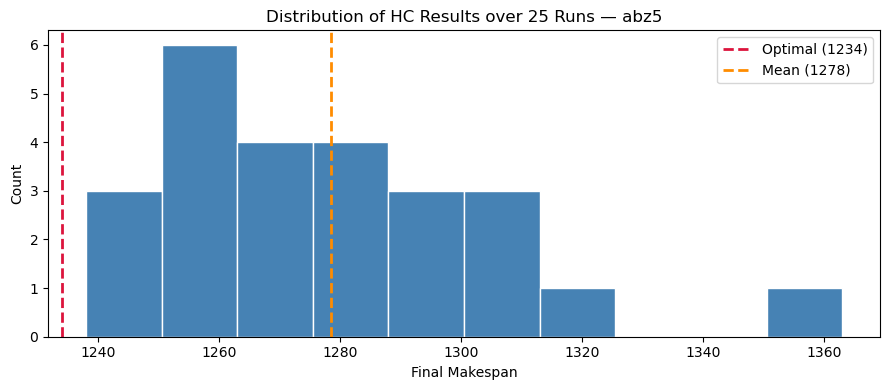

In [8]:
N_RUNS = 25
run_results = []

for _ in range(N_RUNS):
    _, ms, _ = hill_climbing(jobs, n_jobs, n_machines, max_iter=MAX_ITER)
    run_results.append(ms)

print(f"Over {N_RUNS} runs:")
print(f"  Best  : {min(run_results)}")
print(f"  Worst : {max(run_results)}")
print(f"  Mean  : {np.mean(run_results):.1f}")
print(f"  Std   : {np.std(run_results):.1f}")
if opt:
    gaps = [(r - opt) / opt * 100 for r in run_results]
    print(f"  Avg gap from optimal: {np.mean(gaps):.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(run_results, bins=10, color='steelblue', edgecolor='white')
if opt:
    ax.axvline(opt, color='crimson', ls='--', lw=2, label=f'Optimal ({opt})')
ax.axvline(np.mean(run_results), color='darkorange', ls='--', lw=2,
           label=f'Mean ({np.mean(run_results):.0f})')
ax.set_xlabel("Final Makespan")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of HC Results over {N_RUNS} Runs — {INSTANCE_NAME}")
ax.legend()
plt.tight_layout()
plt.show()